In [ ]:
import sys
sys.path.append("../src")
import numpy as np
import random
import pandas as pd

from dataclasses import dataclass
from typing import Tuple, List, Callable, Dict

#import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


from sklearn.preprocessing import OneHotEncoder
from src.utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from src.utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
from utils_online import ForagingPlaygroundLinear, ForagingConfig, EncodeConfig, Encoder

In [3]:
import math, random
from dataclasses import dataclass
from typing import List, Tuple, Optional

In [3]:
# environment setup
# session_duration = 500000
# env_name = 'ForagingPlaygroundLinear-v0'
# register_custom_env(
#     env_name = env_name, 
#     map_name = 'short',
#     base_reward = 10.0,
#     decay_rate = 0.6,
#     reward_period = 10,
#     session_duration = session_duration
# )
# env = gym.make(env_name)

base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [3]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=6):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df

**Function of Training, inference, and evaluation**

In [5]:


# =============== NN ===============
class RewardNet(nn.Module):
    def __init__(self, in_dim:int, hidden:int=128):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(in_dim,hidden), nn.ReLU(),
            nn.Linear(hidden,hidden), nn.ReLU(),
            nn.Linear(hidden,1)
        )
    def forward(self,x:torch.Tensor)->torch.Tensor:
        return self.net(x).squeeze(-1)

# =============== 工具 ===============
def successors(x:int, W:int)->List[int]:
    out=[x]
    if x>0: out.append(x-1)
    if x<W-1: out.append(x+1)
    return out

    
@torch.inference_mode()
def choose_next_by_tree(x_cur:int, t_cur:int, L:int,
                        model:RewardNet, enc:Encoder, env:ForagingPlaygroundLinear) -> int:
    device = next(model.parameters()).device
    gamma  = env.cfg.gamma
    W      = env.cfg.W
    times   = [t_cur + i + 1 for i in range(L)]
    feat_tbl= enc.encode_table(times)                            # [L, W, dim]
    X       = torch.from_numpy(feat_tbl.reshape(L*W, -1)).float().to(device)
    rhat    = model(X).detach().cpu().numpy().reshape(L, W)

    best_score = -1e18
    best_first = x_cur  # fallback
    def dfs(x_now:int, depth:int, total:float):
        nonlocal best_score, best_first
        if depth == L:
            if total > best_score:
                best_score = total
            return
        for nx in successors(x_now, W):
            r_now = (gamma**depth) * float(rhat[depth, nx])
            if depth == 0:
                prev_best = best_score
                dfs(nx, depth+1, total + r_now)
                if best_score > prev_best:
                    best_first = nx
            else:
                dfs(nx, depth+1, total + r_now)
    dfs(x_cur, 0, 0.0)
    return int(best_first)

# =============== Evaluate ===============
def eval_with_utils(env: ForagingPlaygroundLinear,
                          model: RewardNet, enc: Encoder,
                          H:int, L:int, rewards_in_period: np.ndarray,
                          return_paths: bool = True):
    """
    output：
      - preward_model_sum, preward_opt_sum
      - pred_states, optimal_states 
    reward_simulate , compute_normalized_future_rewards from utils
    """
    sim = ForagingPlaygroundLinear(env.cfg)
    sim.x, sim.t = env.x, env.t
    gamma = sim.cfg.gamma

    # 1) Trajectory inference (MCP)
    pred_states = [int(sim.x)]
    cur_x, cur_t = int(sim.x), int(sim.t)
    for _ in range(H):
        nx = choose_next_by_tree(cur_x, cur_t, L, model, enc, sim)
        pred_states.append(nx)
        cur_x, cur_t = nx, cur_t + 1

    # Reward by model    
    irewards_model = [ reward_simulate(pred_states[i], sim.t + i, rewards_in_period)
                       for i in range(1, len(pred_states)) ]  # t+1..t+H
    preward_model  = compute_normalized_future_rewards(irewards_model, H, gamma)
    preward_model_sum = float(np.sum(preward_model))
    # Reward by optimal
    optimal_states, _ = path_opt(int(sim.x), int(sim.t), int(H)) 
    irewards_opt = [reward_simulate(int(optimal_states[i]), sim.t + i, rewards_in_period)for i in range(1, len(optimal_states))   ]                 
    preward_opt   = compute_normalized_future_rewards(irewards_opt, H, gamma)
    preward_opt_sum = float(np.sum(preward_opt))


    

    if return_paths:
        return preward_model_sum, preward_opt_sum, pred_states, list(optimal_states)
    else:
        return preward_model_sum, preward_opt_sum






In [6]:
gamma=0.5

In [ ]:
@dataclass
class TrainConfig:
    total_steps:int=800           
    infer_window:int=100           
    plan_L:int=6                   
    lr:float=1e-2
    hidden:int=128
    replay_cap:int=50000
    batch_size:int=256
    warmup:int=128               
    updates_per_step:int=1        

class Replay:
    def __init__(self, cap:int):
        self.cap=cap
        self.buf:List[Tuple[np.ndarray,float]]=[]
    def push(self, feat:np.ndarray, r:float):
        self.buf.append((feat.astype(np.float32), float(r)))
        if len(self.buf)>self.cap: self.buf.pop(0)
    def sample(self, n:int)->Tuple[torch.Tensor, torch.Tensor]:
        n=min(n, len(self.buf))
        idx=np.random.choice(len(self.buf), size=n, replace=False)
        X=torch.from_numpy(np.stack([self.buf[i][0] for i in idx], axis=0)).float()
        y=torch.from_numpy(np.array([self.buf[i][1] for i in idx], dtype=np.float32))
        return X,y

def build_rewards_in_period(base_reward: float, decay: float, reward_period: int, total_steps: int):
    """Get sequnce of reward"""
    rewards_in_period = []
    for period_start in range(0, total_steps, reward_period):
        period_end = min(period_start + reward_period, total_steps)
        steps_in_period = np.arange(period_start, period_end)
        rewards_in_period.extend(base_reward * (decay ** (steps_in_period - period_start)))
    return np.array(rewards_in_period, dtype=float)

**Main**

In [31]:
def run(seed:int=42):
    # For GPU if avaliable
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    fcfg=ForagingConfig()
    enc_cfg=EncodeConfig(fcfg.W, fcfg.reward_period, fourier_K=3)
    tcfg=TrainConfig(total_steps=500, warmup=256,lr=1e-3)

    env=ForagingPlaygroundLinear(fcfg)
    enc=Encoder(enc_cfg)
    net=RewardNet(enc_cfg.dim, hidden=tcfg.hidden).to(device)
    opt=optim.Adam(net.parameters(), lr=tcfg.lr)
    loss_fn=nn.MSELoss()
    replay=Replay(cap=tcfg.replay_cap)

    extra = 10 * fcfg.reward_period 
    rewards_in_period = build_rewards_in_period(
        fcfg.base_reward, fcfg.decay_rate, fcfg.reward_period,
        total_steps=tcfg.total_steps + tcfg.infer_window+extra
    )

    times=[]           
    norm_regs=[]       # normalized regret
    last_pred_path=None; last_opt_path=None 

    x, t = env.reset()

    for step in range(1, tcfg.total_steps+1):

        # === MPC as well ===
        if step <= tcfg.warmup:
            nx = random.choice(successors(x, fcfg.W))
        else:
            net.eval()
            with torch.inference_mode():
                nx = choose_next_by_tree(x, t, tcfg.plan_L, net, enc, env)


        # Interation with environment
        a = int(np.clip(nx - x, -1, 1))
        x, r_true, t = env.step(a)

        # Online Learning
        feat = enc.encode(x, t)
        replay.push(feat, r_true)
        if len(replay.buf) >= tcfg.batch_size:
            for _ in range(tcfg.updates_per_step):
                net.train()
                Xb, yb = replay.sample(tcfg.batch_size)
                Xb = Xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
                pred = net(Xb); loss = loss_fn(pred, yb)
                opt.zero_grad(set_to_none=True); loss.backward(); opt.step()

        if step > tcfg.warmup+1:
            net.eval()
            with torch.inference_mode():
                prew_model, prew_opt, pred_states, opt_states = eval_with_utils(
                    env, net, enc,
                    H=tcfg.infer_window, L=tcfg.plan_L,
                    rewards_in_period=rewards_in_period,
                    return_paths=True
                )
                risk_nn = -prew_model
                risk_opt = -prew_opt
                regret = risk_nn - risk_opt
                norm_reg = regret / float(tcfg.infer_window)

                last_pred_path = pred_states
                last_opt_path  = opt_states

            times.append(t)
            norm_regs.append(norm_reg)
        if norm_regs: 
            print(f"[t={step}] norm_reg={norm_regs[-1]:.4f}")

    plt.figure(figsize=(10,4))
    plt.plot(times, norm_regs, linestyle="-",
             label=f"Agent")
    plt.axhline(0.0, color="k", linestyle="--", linewidth=0.8, label="optimal")
    plt.axvline(tcfg.warmup, color="gray", linestyle="--", linewidth=0.8, label="Warmup ends")
    plt.title("Normalized Prospective Regret vs Time")
    plt.xlabel("Time steps"); plt.ylabel("Normalized Regret")
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


Device: cpu
[t=258] norm_reg=2.0969
[t=259] norm_reg=2.0300
[t=260] norm_reg=2.1900
[t=261] norm_reg=2.2860
[t=262] norm_reg=2.3438
[t=263] norm_reg=2.3789
[t=264] norm_reg=2.4048
[t=265] norm_reg=2.4203
[t=266] norm_reg=2.4296
[t=267] norm_reg=2.4296
[t=268] norm_reg=2.4295
[t=269] norm_reg=2.4294
[t=270] norm_reg=2.4291
[t=271] norm_reg=2.4286
[t=272] norm_reg=2.4275
[t=273] norm_reg=2.4252
[t=274] norm_reg=2.4208
[t=275] norm_reg=2.4119
[t=276] norm_reg=2.3940
[t=277] norm_reg=2.2083
[t=278] norm_reg=2.0969
[t=279] norm_reg=2.0300
[t=280] norm_reg=2.1900
[t=281] norm_reg=2.2860
[t=282] norm_reg=2.3438
[t=283] norm_reg=2.3789
[t=284] norm_reg=2.4048
[t=285] norm_reg=2.4203
[t=286] norm_reg=2.4296
[t=287] norm_reg=2.4296
[t=288] norm_reg=2.4295
[t=289] norm_reg=2.4294
[t=290] norm_reg=2.4291
[t=291] norm_reg=2.4286
[t=292] norm_reg=2.4275
[t=293] norm_reg=2.4252
[t=294] norm_reg=2.4208
[t=295] norm_reg=2.4119
[t=296] norm_reg=2.3940
[t=297] norm_reg=2.2083
[t=298] norm_reg=2.0969
[t=2

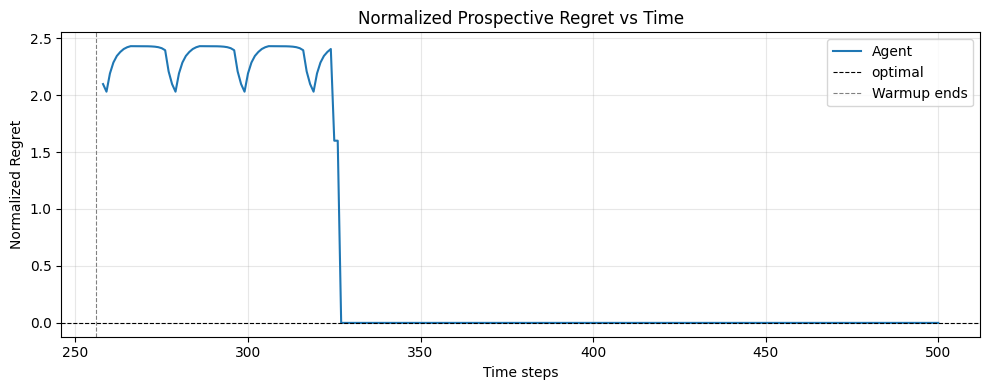

TypeError: cannot unpack non-iterable NoneType object

In [33]:
last_pred_path,last_opt_path=run()

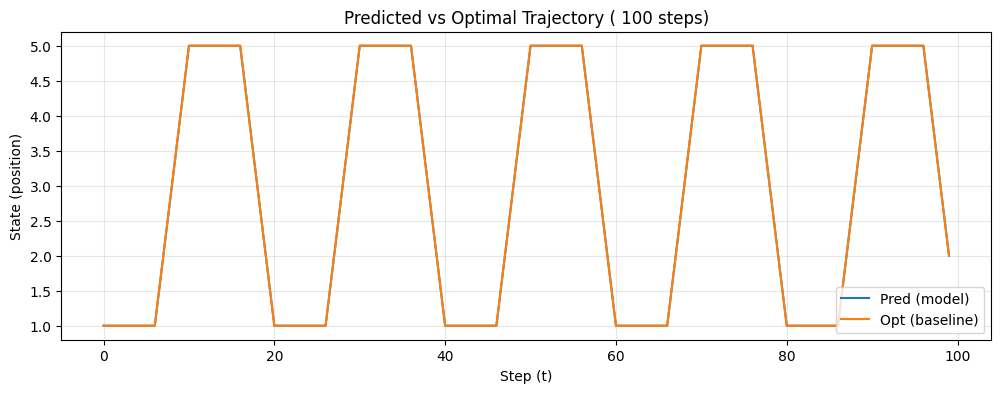

In [ ]:
import matplotlib.pyplot as plt

def plot_pred_vs_opt(last_pred_path, last_opt_path, horizon=100):
    steps = range(horizon)
    pred = last_pred_path[:horizon]
    opt  = last_opt_path[:horizon]

    plt.figure(figsize=(12,4))
    plt.plot(steps, pred, label="Pred (model)")
    plt.plot(steps, opt,  label="Opt (baseline)")
    plt.xlabel("Step (t)")
    plt.ylabel("State (position)")
    plt.title(f"Predicted vs Optimal Trajectory ( {horizon} steps)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_pred_vs_opt(last_pred_path, last_opt_path, horizon=100)
